# Exploración, preparación y modelado del ETF VOO

Este notebook desarrolla el proceso metodológico para construir un modelo de aprendizaje de máquina orientado a apoyar decisiones de inversión sobre el ETF VOO, un fondo indexado de Vanguard que replica el comportamiento del índice S&P 500.

El objetivo del proyecto no es predecir el mercado financiero con certeza, sino construir un sistema de apoyo que, a partir de datos históricos, estime si existen condiciones favorables para una posible oportunidad de inversión en un horizonte temporal definido.

La metodología se desarrolla en varias etapas: primero se realiza la carga y exploración del dataset, luego se limpian y transforman las variables originales, posteriormente se construyen variables derivadas del comportamiento histórico del precio y finalmente se comparan diferentes modelos de clasificación supervisada.

Este enfoque es coherente con el objetivo del proyecto final, ya que se requiere comparar al menos tres tipos de modelos de aprendizaje de máquina y construir una aplicación simple para usuario final que utilice el modelo seleccionado.

## 1. Carga de librerías y configuración inicial

En esta sección se importan las librerías necesarias para el análisis. Se utilizan librerías estándar para manipulación de datos, visualización y modelado.

En esta etapa inicial todavía no se entrenan modelos. El propósito es preparar el entorno de trabajo y definir rutas del proyecto de manera ordenada para que el notebook pueda ejecutarse de forma reproducible desde la estructura del repositorio.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

ruta_proyecto = Path.cwd()

if ruta_proyecto.name == "notebooks":
    ruta_proyecto = ruta_proyecto.parents[1]

ruta_datos = ruta_proyecto / "code" / "data" / "raw" / "voo_etf_stock_price_history.csv"
ruta_modelos = ruta_proyecto / "code" / "models"
ruta_figuras = ruta_proyecto / "code" / "outputs" / "figures"
ruta_tablas = ruta_proyecto / "code" / "outputs" / "tables"

ruta_modelos.mkdir(parents=True, exist_ok=True)
ruta_figuras.mkdir(parents=True, exist_ok=True)
ruta_tablas.mkdir(parents=True, exist_ok=True)

ruta_datos

PosixPath('/Users/jacoboorozco/Documents/Dev/AP/Proyecto_Final/Proyecto_Final_AP/code/data/raw/voo_etf_stock_price_history.csv')

## 2. Carga del dataset original

El dataset contiene información histórica del ETF VOO. Las columnas originales incluyen la fecha de negociación, el precio de cierre, el precio de apertura, el precio máximo, el precio mínimo, el volumen transado y el porcentaje de cambio diario.

En esta primera lectura se conserva el archivo tal como viene originalmente. Esto permite inspeccionar su estructura antes de aplicar transformaciones, evitando modificar datos sin entender primero su formato.

In [3]:
datos_crudos = pd.read_csv(ruta_datos)

print(f"Filas del dataset original: {datos_crudos.shape[0]}")
print(f"Columnas del dataset original: {datos_crudos.shape[1]}")

display(datos_crudos.head())
display(datos_crudos.tail())

Filas del dataset original: 3879
Columnas del dataset original: 7


,Date,Price,Open,High,Low,Vol.,Change %
0,04/24/2026,656.42,653.40,656.82,651.82,4.79M,0.79%
1,04/23/2026,651.26,652.23,654.90,645.66,6.52M,-0.40%
2,04/22/2026,653.90,651.98,654.19,651.09,4.54M,1.03%
3,04/21/2026,647.25,652.94,653.86,645.94,8.51M,-0.66%
4,04/20/2026,651.54,651.62,652.60,649.17,6.38M,-0.19%


,Date,Price,Open,High,Low,Vol.,Change %
3874,01/07/2011,116.31,116.70,116.86,115.48,82.24K,-0.20%
3875,01/06/2011,116.54,116.84,116.92,116.22,72.42K,-0.17%
3876,01/05/2011,116.74,115.86,116.80,115.72,717.74K,0.53%
3877,01/04/2011,116.12,116.56,116.56,115.50,108.33K,-0.09%
3878,01/03/2011,116.22,115.94,116.66,115.90,119.18K,0.94%


## 3. Inspección inicial de estructura y calidad de datos

Antes de construir cualquier modelo, es necesario revisar la calidad del dataset. En particular, se inspeccionan los nombres de las columnas, los tipos de datos, la cantidad de valores nulos y la posible existencia de registros duplicados.

Esta revisión es importante porque los modelos de aprendizaje de máquina requieren variables numéricas limpias y consistentes. Además, como se trata de una serie temporal financiera, también será necesario verificar posteriormente que las fechas estén correctamente interpretadas y ordenadas de forma cronológica.

In [4]:
print("Columnas del dataset:")
print(datos_crudos.columns.tolist())

print("\nInformación general:")
datos_crudos.info()

print("\nValores nulos por columna:")
display(datos_crudos.isna().sum())

print("\nCantidad de registros duplicados:")
print(datos_crudos.duplicated().sum())

Columnas del dataset:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 3879 entries, 0 to 3878
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      3879 non-null   str    
 1   Price     3879 non-null   float64
 2   Open      3879 non-null   float64
 3   High      3879 non-null   float64
 4   Low       3879 non-null   float64
 5   Vol.      3850 non-null   str    
 6   Change %  3879 non-null   str    
dtypes: float64(4), str(3)
memory usage: 291.6 KB

Valores nulos por columna:


Date         0
Price        0
Open         0
High         0
Low          0
Vol.        29
Change %     0
dtype: int64


Cantidad de registros duplicados:
0


## 4. Funciones auxiliares para conversión de formatos

El archivo CSV contiene algunas variables numéricas almacenadas como texto. Por ejemplo, los precios pueden incluir separadores de miles, el volumen puede estar abreviado con letras como `K`, `M` o `B`, y el cambio porcentual incluye el símbolo `%`.

Para evitar repetir lógica de limpieza en varias partes del notebook, se definen funciones auxiliares. Estas funciones se documentan con un formato compatible con MkDocs, especificando su propósito, parámetros, retorno y posibles consideraciones.

In [5]:
def convertir_precio_a_float(valor_original):
    """
    Convierte un valor de precio del dataset a número decimal.

    Esta función limpia valores de precio que pueden venir como texto,
    eliminando separadores de miles y espacios antes de convertirlos
    a tipo `float`.

    Args:
        valor_original: Valor original de una columna de precio.

    Returns:
        Valor numérico convertido a `float`. Si el valor original es nulo,
        retorna `np.nan`.
    """
    if pd.isna(valor_original):
        return np.nan

    valor_limpio = str(valor_original).replace(",", "").strip()

    return float(valor_limpio)


def convertir_porcentaje_a_decimal(valor_original):
    """
    Convierte un porcentaje textual a proporción decimal.

    Por ejemplo, el valor `"1.25%"` se transforma en `0.0125`.

    Args:
        valor_original: Valor original de la columna porcentual.

    Returns:
        Valor porcentual convertido a proporción decimal. Si el valor
        original es nulo, retorna `np.nan`.
    """
    if pd.isna(valor_original):
        return np.nan

    valor_limpio = str(valor_original).replace("%", "").replace(",", "").strip()

    return float(valor_limpio) / 100


def convertir_volumen_a_float(valor_original):
    """
    Convierte el volumen transado a valor numérico.

    El dataset puede representar el volumen con abreviaciones como `K`
    para miles, `M` para millones o `B` para miles de millones.

    Args:
        valor_original: Valor original de la columna de volumen.

    Returns:
        Volumen convertido a `float`. Si el valor original es nulo o no
        contiene información válida, retorna `np.nan`.
    """
    if pd.isna(valor_original):
        return np.nan

    valor_texto = str(valor_original).replace(",", "").strip().upper()

    if valor_texto in {"", "-", "NAN"}:
        return np.nan

    multiplicador = 1.0

    if valor_texto.endswith("K"):
        multiplicador = 1_000
        valor_texto = valor_texto[:-1]
    elif valor_texto.endswith("M"):
        multiplicador = 1_000_000
        valor_texto = valor_texto[:-1]
    elif valor_texto.endswith("B"):
        multiplicador = 1_000_000_000
        valor_texto = valor_texto[:-1]

    return float(valor_texto) * multiplicador

## 5. Limpieza inicial del dataset

En esta sección se construye una versión limpia del dataset. Para ello se convierte la fecha a formato temporal, se transforman las variables de precio y volumen a valores numéricos, y se estandarizan los nombres de las columnas.

También se ordenan los registros de forma ascendente por fecha. Este paso es fundamental porque los modelos no deben entrenarse mezclando observaciones futuras con observaciones pasadas. En problemas financieros y de series de tiempo, conservar el orden cronológico es una condición metodológica necesaria.

In [6]:
datos_voo = datos_crudos.copy()

datos_voo["fecha"] = pd.to_datetime(datos_voo["Date"])
datos_voo["precio_cierre"] = datos_voo["Price"].apply(convertir_precio_a_float)
datos_voo["precio_apertura"] = datos_voo["Open"].apply(convertir_precio_a_float)
datos_voo["precio_maximo"] = datos_voo["High"].apply(convertir_precio_a_float)
datos_voo["precio_minimo"] = datos_voo["Low"].apply(convertir_precio_a_float)
datos_voo["volumen"] = datos_voo["Vol."].apply(convertir_volumen_a_float)
datos_voo["cambio_porcentual"] = datos_voo["Change %"].apply(convertir_porcentaje_a_decimal)

columnas_limpias = [
    "fecha",
    "precio_cierre",
    "precio_apertura",
    "precio_maximo",
    "precio_minimo",
    "volumen",
    "cambio_porcentual",
]

datos_voo = datos_voo[columnas_limpias]
datos_voo = datos_voo.sort_values("fecha").reset_index(drop=True)

display(datos_voo.head())
display(datos_voo.tail())

,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
0,2011-01-03,116.22,115.94,116.66,115.90,119180.0,0.0094
1,2011-01-04,116.12,116.56,116.56,115.50,108330.0,-0.0009
2,2011-01-05,116.74,115.86,116.80,115.72,717740.0,0.0053
3,2011-01-06,116.54,116.84,116.92,116.22,72420.0,-0.0017
4,2011-01-07,116.31,116.70,116.86,115.48,82240.0,-0.0020


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
3874,2026-04-20,651.54,651.62,652.60,649.17,6380000.0,-0.0019
3875,2026-04-21,647.25,652.94,653.86,645.94,8510000.0,-0.0066
3876,2026-04-22,653.90,651.98,654.19,651.09,4540000.0,0.0103
3877,2026-04-23,651.26,652.23,654.90,645.66,6520000.0,-0.0040
3878,2026-04-24,656.42,653.40,656.82,651.82,4790000.0,0.0079


## 6. Validación posterior a la limpieza

Después de transformar el dataset, se revisa nuevamente su estructura para confirmar que las variables quedaron en formatos adecuados. En particular, se verifica el rango de fechas, la cantidad de valores nulos y los principales estadísticos descriptivos.

Esta validación permite detectar problemas antes de crear variables derivadas o entrenar modelos. Si se ignora esta etapa, se corre el riesgo de construir modelos sobre datos mal interpretados.

In [7]:
print(f"Cantidad de registros después de limpieza: {datos_voo.shape[0]}")
print(f"Cantidad de columnas después de limpieza: {datos_voo.shape[1]}")

print(f"\nFecha mínima: {datos_voo['fecha'].min()}")
print(f"Fecha máxima: {datos_voo['fecha'].max()}")

print("\nTipos de datos:")
display(datos_voo.dtypes)

print("\nValores nulos después de limpieza:")
display(datos_voo.isna().sum())

print("\nResumen estadístico:")
display(datos_voo.describe())

Cantidad de registros después de limpieza: 3879
Cantidad de columnas después de limpieza: 7

Fecha mínima: 2011-01-03 00:00:00
Fecha máxima: 2026-04-24 00:00:00

Tipos de datos:


fecha                datetime64[us]
precio_cierre               float64
precio_apertura             float64
precio_maximo               float64
precio_minimo               float64
volumen                     float64
cambio_porcentual           float64
dtype: object


Valores nulos después de limpieza:


fecha                 0
precio_cierre         0
precio_apertura       0
precio_maximo         0
precio_minimo         0
volumen              29
cambio_porcentual     0
dtype: int64


Resumen estadístico:


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
count,3879,3879.000000,3879.000000,3879.000000,3879.000000,3.850000e+03,3879.000000
mean,2018-09-01 16:05:34.106728,288.352472,288.309363,289.778958,286.691114,3.292032e+06,0.000507
min,2011-01-03 00:00:00,100.340000,99.140000,102.820000,98.240000,4.044000e+04,-0.117400
25%,2014-11-08 12:00:00,180.320000,180.280000,181.165000,179.500000,1.240000e+06,-0.003700
50%,2018-09-17 00:00:00,251.870000,251.920000,253.010000,250.170000,2.605000e+06,0.000600
75%,2022-06-11 12:00:00,385.245000,385.515000,387.255000,383.180000,4.380000e+06,0.005700
max,2026-04-24 00:00:00,656.420000,653.400000,656.820000,651.820000,3.706000e+07,0.095400
std,NaN,141.001029,140.972348,141.695599,140.178246,3.234115e+06,0.010772


## Interpretación de la inspección inicial

El dataset original contiene 3.879 registros y 7 columnas: `Date`, `Price`, `Open`, `High`, `Low`, `Vol.` y `Change %`. Cada registro representa un día de negociación del ETF VOO.

En la vista inicial se observa que los datos vienen ordenados de forma descendente, es decir, desde la fecha más reciente hacia la más antigua. Por esta razón fue necesario ordenar el dataset de forma ascendente por fecha, ya que en un problema financiero con estructura temporal no se deben mezclar observaciones futuras con observaciones pasadas.

Después de la limpieza, el dataset queda con las siguientes variables estandarizadas:

- `fecha`: fecha de negociación.
- `precio_cierre`: precio de cierre del ETF.
- `precio_apertura`: precio de apertura.
- `precio_maximo`: precio máximo del día.
- `precio_minimo`: precio mínimo del día.
- `volumen`: volumen transado.
- `cambio_porcentual`: variación porcentual diaria expresada como decimal.

El rango temporal va desde el 3 de enero de 2011 hasta el 24 de abril de 2026. Esto proporciona una serie histórica suficientemente amplia para analizar el comportamiento del activo en diferentes contextos de mercado.

No se encontraron registros duplicados. Sin embargo, se identificaron 29 valores nulos en la variable `volumen`. Esta cantidad representa una proporción baja del dataset, pero debe tratarse antes de entrenar modelos, especialmente si se van a construir variables derivadas del volumen. En cambio, las columnas de precio y cambio porcentual no presentan valores faltantes.

El resumen estadístico muestra una tendencia creciente clara en el precio de VOO durante el periodo analizado. El precio de cierre pasa de valores cercanos a 116 USD en 2011 hasta valores superiores a 650 USD en 2026. Esta tendencia es esperable en un ETF asociado al S&P 500, pero también implica que el modelo no debe basarse únicamente en niveles absolutos de precio. Por esta razón, más adelante se construirán variables relativas como retornos, medias móviles, volatilidad, momentum y distancia frente a máximos o mínimos recientes.

## 7. Análisis de valores faltantes en la variable volumen

Aunque la cantidad de valores nulos en `volumen` es baja, se revisan explícitamente estos registros para entender si corresponden a fechas aisladas o si siguen algún patrón temporal.

Esta revisión es importante porque el volumen puede ser utilizado posteriormente para construir variables relacionadas con actividad de mercado. Si los valores faltantes se concentran en un periodo específico, podrían reflejar un problema de calidad de datos en esa zona de la serie. Si están dispersos, pueden tratarse mediante imputación simple sin afectar de manera significativa el análisis.

In [8]:
registros_volumen_nulo = datos_voo[datos_voo["volumen"].isna()].copy()

print(f"Cantidad de registros con volumen nulo: {registros_volumen_nulo.shape[0]}")

display(registros_volumen_nulo)

Cantidad de registros con volumen nulo: 29


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
2295,2020-02-17,310.28,310.28,310.28,310.28,NaN,0.0
2315,2020-03-14,247.64,247.64,247.64,247.64,NaN,0.0
2321,2020-03-21,210.74,210.74,210.74,210.74,NaN,0.0
2327,2020-03-28,232.86,232.86,232.86,232.86,NaN,0.0
2352,2020-05-02,259.82,259.82,259.82,259.82,NaN,0.0
2353,2020-05-03,259.82,259.82,259.82,259.82,NaN,0.0
2378,2020-06-07,293.61,293.61,293.61,293.61,NaN,0.0
2398,2020-07-04,286.81,286.81,286.81,286.81,NaN,0.0
2399,2020-07-05,286.81,286.81,286.81,286.81,NaN,0.0
2405,2020-07-11,291.80,291.80,291.80,291.80,NaN,0.0


In [9]:
porcentaje_volumen_nulo = datos_voo["volumen"].isna().mean() * 100

print(f"Porcentaje de registros con volumen nulo: {porcentaje_volumen_nulo:.2f}%")

Porcentaje de registros con volumen nulo: 0.75%


## 8. Comportamiento histórico del precio de cierre

Se visualiza la evolución del precio de cierre del ETF VOO a lo largo del tiempo. Esta gráfica permite entender la tendencia general del activo y detectar visualmente periodos de crecimiento, caídas pronunciadas o alta volatilidad.

Esta visualización también ayuda a justificar que el problema no debe formularse como una simple predicción del nivel absoluto de precio. En una serie con tendencia creciente, el precio actual suele ser mayor que el precio de años anteriores, por lo que el modelo podría aprender relaciones débiles si se usan únicamente valores absolutos. Por eso, en etapas posteriores se crearán variables relativas basadas en retornos, volatilidad y comportamiento reciente.

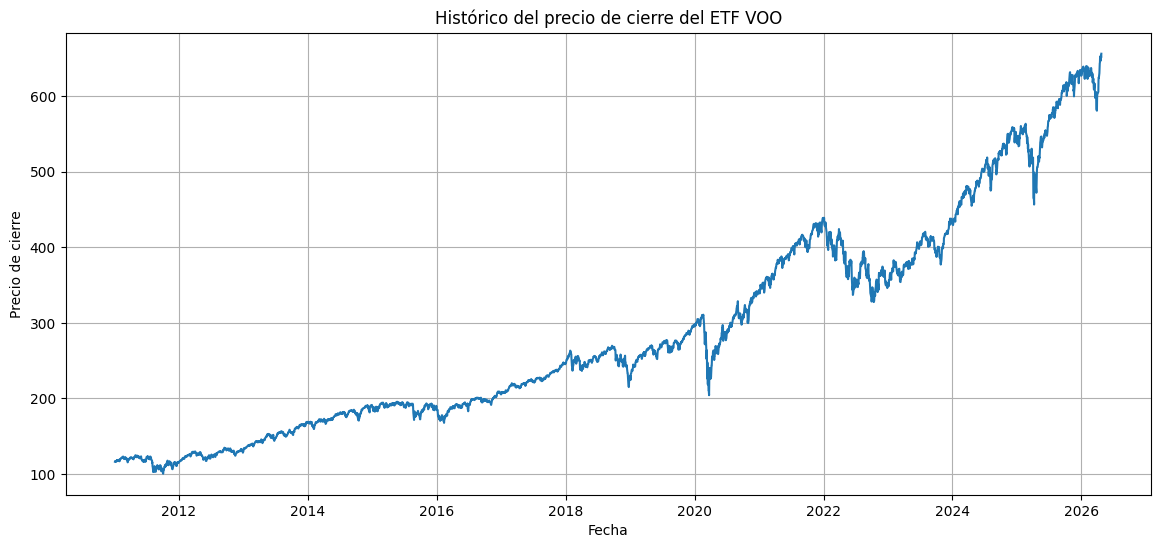

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(datos_voo["fecha"], datos_voo["precio_cierre"])
plt.title("Histórico del precio de cierre del ETF VOO")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.show()